# Compare Ensino Fundamental vs Ensino Medio

**Living Stone Foundation - Applied Data Lab**

**Audience:** team leads / reviewers who need a clear reason for **two models and two Streamlit apps**.

**Core question:** Do dropout levels and school-trait associations differ enough between Fundamental and Medio that a single pooled Brazil model would be misleading?


## Variable dictionary (read before the charts)

| Column / label in charts | Plain-English meaning | How to read values |
|---|---|---|
| `target_dropout_rate` / **Dropout rate (%)** | Official INEP "taxa de abandono": share of students who **stopped attending** during the school year, after the Census reference date | 0 = nobody left; 5 = 5% left. Higher = worse |
| `year` | School Census / attainment-rate year | Years present in the mart (currently 2018-2025) |
| `school_id` (`CO_ENTIDADE`) | Unique school code (INEP) | Join key between Census and attainment-rate data |
| `state_code` | Brazilian state abbreviation ("UF" = Unidade Federativa) | e.g. SP, BA, AM |
| `municipality_id` | IBGE municipality code | Geographic context |
| `admin_dependency_type` | Administrative network | 1=Federal, 2=State, 3=Municipal, 4=Private |
| `location_type` | School location type | 1=Urban, 2=Rural |
| `is_rural` | 1 if rural school | Shortcut of `location_type == 2` |
| `is_public` | 1 if public network (federal/state/municipal) | 0 = private |
| `has_water` | Has potable / public water | 1=yes, 0=no |
| `has_electricity` | Connected to public electricity | 1=yes, 0=no |
| `has_sewage` | Public sewage connection | 1=yes, 0=no |
| `has_internet` / `has_internet_for_students` | Internet at school / specifically available to students | 1=yes, 0=no |
| `has_library` | Library / reading room | 1=yes, 0=no |
| `has_computer_lab` | Computer lab | 1=yes, 0=no |
| `has_sports_court` | Sports court | 1=yes, 0=no |
| `enrollment_basic_ed` | Enrollment count (basic education total, when available) | Larger = bigger school |
| `enrollment_level` | Enrollment used for this level (Fundamental or Medio) | Filter requires >= 20 students |
| `teacher_count_basic_ed` | Number of teachers (basic education) | Staffing intensity |
| `student_teacher_ratio` | Students / teachers | Higher often means more crowded classes |
| `avg_class_size` | Enrollment / number of classes for this level | Higher = larger classes |
| `overage_enrollment_share` | Share of students above the expected age for this level | A known proxy for grade-age distortion, itself a dropout correlate |
| `dropout_rate_lag1` / `_lag2` | This school's own dropout rate 1 / 2 years earlier | Missing (NaN) for a school's first year in the panel |
| `dropout_rate_3yr_avg` / `_trend` | Trailing 3-year average / (lag1 - lag2) | Trend > 0 means the rate has been rising |
| `has_history` | 1 if the school has at least one prior year on record | 0 = first appearance in the 2018-2025 window |
| `approval_rate_lag1` / `failure_rate_lag1` | This school's own approval / grade-repetition rate, prior year | A rising failure rate is a known leading indicator of dropout |
| `municipal_dropout_rate_lag1` / `state_dropout_rate_lag1` | Average dropout rate across the municipality / state, prior year | A spatial-lag signal for local shocks a single school's history cannot capture |
| `is_covid_year` | 1 for school years 2020-2021 | INEP suspended normal grade-progression rules in these years |
| `risk_band` | low / moderate / high | Relative triage label inside the level |
| `high_risk` | 1 if school is in the elevated-risk group | Binary flag used for the triage/ranking metrics |
| **MAE / RMSE / R2** | Model error metrics (later notebooks / model folder) | Lower MAE/RMSE better; R2 closer to 1 better |

### Acronyms
| Acronym | Meaning |
|---|---|
| **INEP** | Brazil's federal education-statistics agency |
| **School Census** ("Censo Escolar") | Annual school census (structure + enrollment) |
| **School Attainment Rates** ("Taxas de Rendimento") | Official approval / failure / dropout rates |
| **EDA** | Exploratory Data Analysis |
| **UF** | Unidade Federativa (Brazilian state) |
| **Fundamental** | Ensino Fundamental: grades 1-9, roughly ages 6-14 |
| **Medio** | Ensino Medio: grades 10-12, Brazil's upper-secondary stage |
| **EJA** | Educacao de Jovens e Adultos (adult / youth education track) |


In [1]:
# Cell A - project path only (no Path.cwd / exists / resolve)
import sys
ROOT = r"C:\Users\User\Desktop\Projeto Living Stone Foundation"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


### What this cell did
Added the project folder to Python's import path using a **fixed string** (no `Path.cwd()` / `exists` / `resolve`). Those path checks can freeze kernels on Desktop/OneDrive.


In [2]:
# Cell B - imports (first run can take a minute for pandas/seaborn)
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

FEATURE_LABELS = {
    "is_rural": "Rural school (1=yes)",
    "is_public": "Public network (1=yes)",
    "has_internet": "Has internet (1=yes)",
    "has_internet_for_students": "Has internet for students (1=yes)",
    "has_computer_lab": "Has computer lab (1=yes)",
    "has_sports_court": "Has sports court (1=yes)",
    "has_library": "Has library (1=yes)",
    "has_water": "Has water (1=yes)",
    "has_electricity": "Has electricity (1=yes)",
    "has_sewage": "Has sewage (1=yes)",
    "enrollment_level": "Enrollment (this level)",
    "enrollment_basic_ed": "Basic-ed enrollment (total)",
    "teacher_count_basic_ed": "Number of teachers",
    "student_teacher_ratio": "Students per teacher",
    "avg_class_size": "Average class size",
    "overage_enrollment_share": "Share of over-age students",
    "admin_dependency_type": "Admin network code",
    "location_type": "Urban/rural code",
    "target_dropout_rate": "Dropout rate (%)",
    "dropout_rate_lag1": "Dropout rate, prior year",
    "dropout_rate_lag2": "Dropout rate, 2 years prior",
    "dropout_rate_3yr_avg": "Dropout rate, 3-year trailing avg",
    "dropout_rate_trend": "Dropout rate trend",
    "approval_rate_lag1": "Approval rate, prior year",
    "failure_rate_lag1": "Failure rate, prior year",
    "municipal_dropout_rate_lag1": "Municipality's dropout rate, prior year",
    "state_dropout_rate_lag1": "State's dropout rate, prior year",
}
from src.eda import compare_levels, load_level_mart
print("Imports OK")


Imports OK


### What this cell did
Loaded charting/table libraries. The **first** run can take ~30-90s while pandas/seaborn warm up - that is normal, not a freeze on `import sys`.


In [3]:
summary = compare_levels().rename(columns={
    'level': 'Education level',
    'rows': 'School-year rows',
    'schools': 'Unique schools',
    'mean_dropout_rate': 'Mean dropout rate (%)',
    'median_dropout_rate': 'Median dropout rate (%)',
    'p90_dropout_rate': '90th percentile (%)',
    'public_share': 'Share public',
    'rural_share': 'Share rural',
    'share_with_history': 'Share with prior-year history',
})
display(summary)
fund = load_level_mart('fundamental')
med = load_level_mart('medio')
print('Loaded Fundamental rows:', len(fund), '| Medio rows:', len(med))


,Education level,School-year rows,Unique schools,Mean dropout rate (%),Median dropout rate (%),90th percentile (%),Share public,Share rural,Share with prior-year history
0,fundamental,832326,122211,1.142,0.000,3.300,0.799,0.313,0.856
1,medio,225199,32612,3.314,0.500,10.200,0.722,0.104,0.858


Loaded Fundamental rows: 832326 | Medio rows: 225199


### How to read this summary
Compare the two rows:
- **Mean / 90th percentile dropout rate** - is Medio systematically "harder"?
- **Row counts** - Medio has fewer schools (only those offering upper secondary).
- **Public / rural shares** - different school mixes can change which features matter.

### Insight
A higher Medio mean with fewer schools already suggests **different operating regimes**. That is necessary (but not sufficient) evidence for separate models - the next charts check the shape of risk and the correlates.


## 1. Outcome shape: boxplots side by side


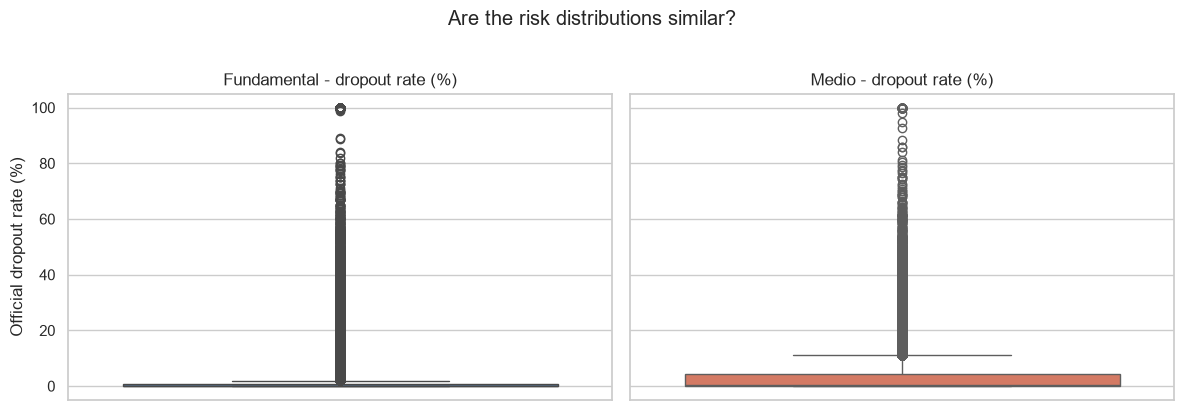

Mean Fundamental: 1.14%
Mean Medio:       3.31%
P90 Fundamental:  3.30%
P90 Medio:        10.20%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.boxplot(data=fund, y='target_dropout_rate', ax=ax[0], color='#4c78a8')
ax[0].set_title('Fundamental - dropout rate (%)')
ax[0].set_ylabel('Official dropout rate (%)')
sns.boxplot(data=med, y='target_dropout_rate', ax=ax[1], color='#e76f51')
ax[1].set_title('Medio - dropout rate (%)')
ax[1].set_ylabel('')
plt.suptitle('Are the risk distributions similar?', y=1.02)
plt.tight_layout()
plt.show()
print('Mean Fundamental: {:.2f}%'.format(fund['target_dropout_rate'].mean()))
print('Mean Medio:       {:.2f}%'.format(med['target_dropout_rate'].mean()))
print('P90 Fundamental:  {:.2f}%'.format(fund['target_dropout_rate'].quantile(0.9)))
print('P90 Medio:        {:.2f}%'.format(med['target_dropout_rate'].quantile(0.9)))


### How to read a boxplot (30-second guide)
- The **box** = middle 50% of schools.
- The line inside = **median** (half the schools are below it).
- Dots / whiskers show the spread and extreme schools.

If Medio's box and whiskers sit **higher** or stretch farther than Fundamental's, the levels do not share the same typical risk.

### Insight
When the distributions differ, a pooled model tends to under-serve one level (often Medio). Separate models keep errors and explanations honest per stage.


## 2. Do the associated school traits differ?


,Fundamental,Medio
Rural school (1=yes),0.106,0.103
Public network (1=yes),0.070,0.293
Has internet (1=yes),-0.165,-0.127
Has computer lab (1=yes),-0.067,-0.034
Has sports court (1=yes),-0.104,-0.135
Has library (1=yes),-0.048,-0.026
Enrollment (this level),-0.048,0.129
"Dropout rate, prior year",0.309,0.432
Students per teacher,0.013,0.147


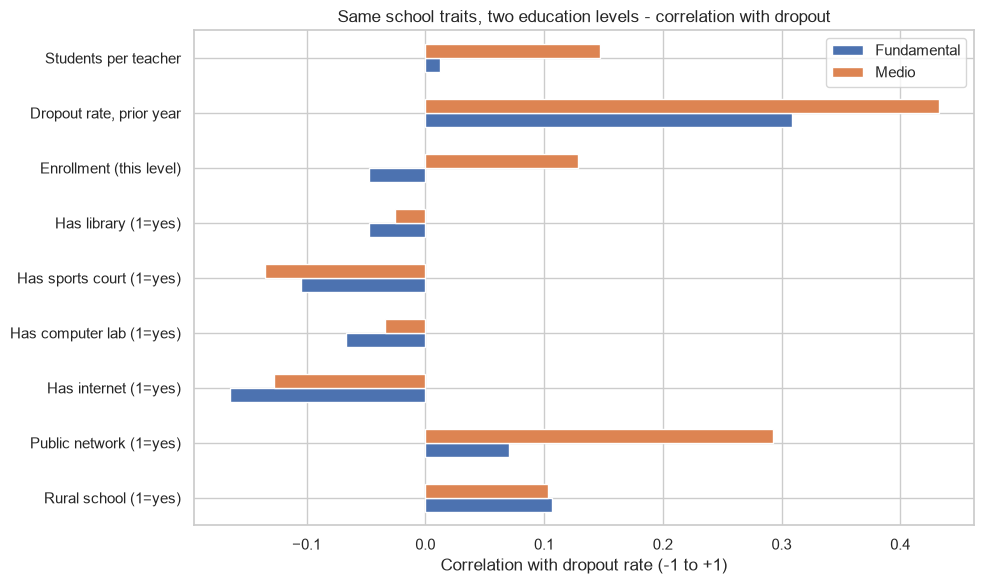

In [5]:
def top_corr(df):
    cols = ['is_rural', 'is_public', 'has_internet', 'has_computer_lab', 'has_sports_court',
            'has_library', 'enrollment_level', 'dropout_rate_lag1']
    tmp = df.copy()
    tmp['student_teacher_ratio'] = tmp['enrollment_level'] / tmp['teacher_count_basic_ed'].replace({0: pd.NA})
    cols = [c for c in cols + ['student_teacher_ratio'] if c in tmp.columns]
    s = tmp[cols + ['target_dropout_rate']].corr(numeric_only=True)['target_dropout_rate'].drop('target_dropout_rate')
    return s.rename(index=FEATURE_LABELS)

cmp = pd.DataFrame({
    'Fundamental': top_corr(fund),
    'Medio': top_corr(med),
})
display(cmp)
ax = cmp.plot(kind='barh', figsize=(10, 6))
ax.set_title('Same school traits, two education levels - correlation with dropout')
ax.set_xlabel('Correlation with dropout rate (-1 to +1)')
plt.tight_layout()
plt.show()


### How to read this comparison chart
- Each horizontal pair of bars is **one school trait** (see dictionary above), now including `dropout_rate_lag1` for direct comparison against the Census features.
- Ask:
  1. Do the **signs** agree (both positive or both negative)?
  2. Do the **magnitudes** differ a lot?
  3. Is the **ranking** of strongest traits different?

### Insight (argument for two Streamlit apps)
If Fundamental is more tied to **infrastructure / rurality** while Medio is more tied to **school size / staffing (students per teacher)** - with both levels agreeing that dropout history is the single strongest signal - then:
- counselors need **different explanation templates** per level, but the same history-first triage logic;
- one shared "top 5 drivers" list would mislead users about the Census-feature ranking specifically;
- therefore **two models + two apps** is the scientifically cleaner product design.

Still remember: correlations are associations, not proof of cause.


## 3. Trained-model drivers (if models already exist)


In [6]:
rows = []
for level, label in [('fundamental', 'Fundamental'), ('medio', 'Medio')]:
    path = Path(ROOT) / 'models' / level / 'figures' / 'global_importance_top.csv'
    try:
        imp = pd.read_csv(path).head(8)
        imp['level'] = label
        imp['feature_label'] = imp['feature'].map(FEATURE_LABELS).fillna(imp['feature'])
        rows.append(imp)
    except FileNotFoundError:
        pass
if rows:
    both = pd.concat(rows, ignore_index=True)
    display(both[['level', 'feature_label', 'importance']])
else:
    print('Train models first: python -m src.train --level both')


,level,feature_label,importance
0,Fundamental,"Dropout rate, 3-year trailing avg",0.239
1,Fundamental,Share of over-age students,0.102
2,Fundamental,"Municipality's dropout rate, prior year",0.078
3,Fundamental,"State's dropout rate, prior year",0.059
4,Fundamental,Average class size,0.042
5,Fundamental,Students per teacher,0.041
6,Fundamental,Basic-ed enrollment (total),0.038
7,Fundamental,Number of teachers,0.037
8,Medio,"Dropout rate, 3-year trailing avg",0.335
9,Medio,Share of over-age students,0.073


### How to read this table
For each level, features are ordered by how much the **selected model** relies on them when predicting dropout.

### Final insight for reviewers
1. Official labels + Brazil basic education means population/data alignment is restored (see `docs/scope_revision.md`).
2. Fundamental and Medio differ in **level** and often in **drivers**.
3. Dual products are a narrowing of scope (one country), not a return to multi-country sprawl.
4. Every reported metric here should be read next to its trivial-baseline comparison in `models/{level}/metrics.json` - see `docs/validity_and_english_revision.md`.
5. Apps must show the limitation: **school triage**, not student scoring.
